# Evaluating different models visullay

In [1]:
import os
import pandas as pd

# --- Path Config ---
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
STATS_DIR = os.path.join(OUTPUTS_DIR, "statistics")
PLOTS_DIR = os.path.join(OUTPUTS_DIR, "plots")
METRICS_DIR = os.path.join(OUTPUTS_DIR, "metrics")

# Make sure subfolders exist
os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

eval_plots_dir = os.path.join(PLOTS_DIR, "part13_evaluation")
os.makedirs(eval_plots_dir, exist_ok=True)



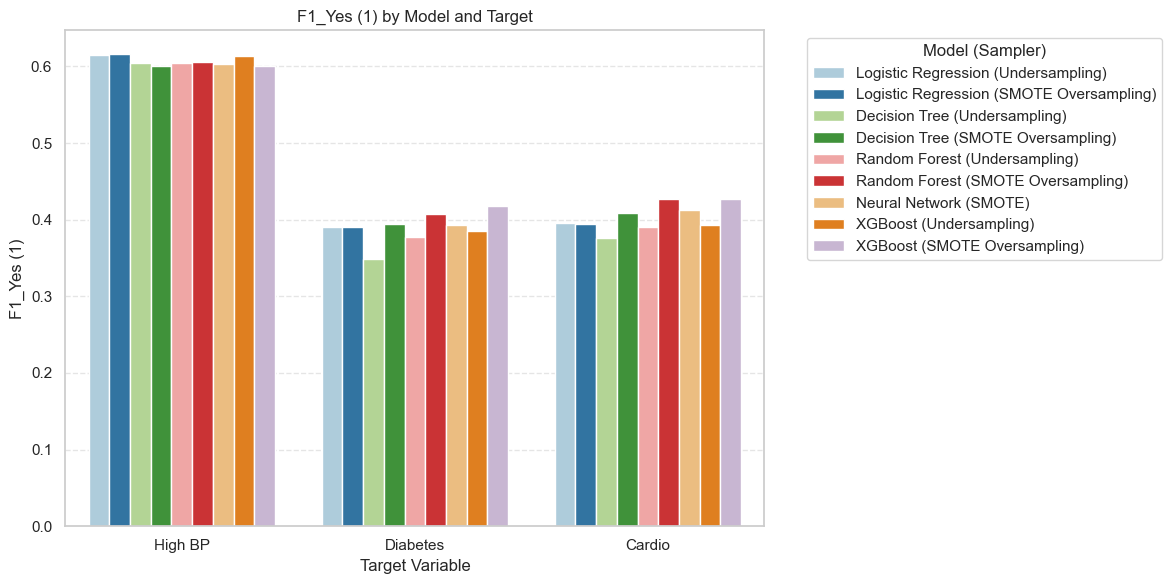

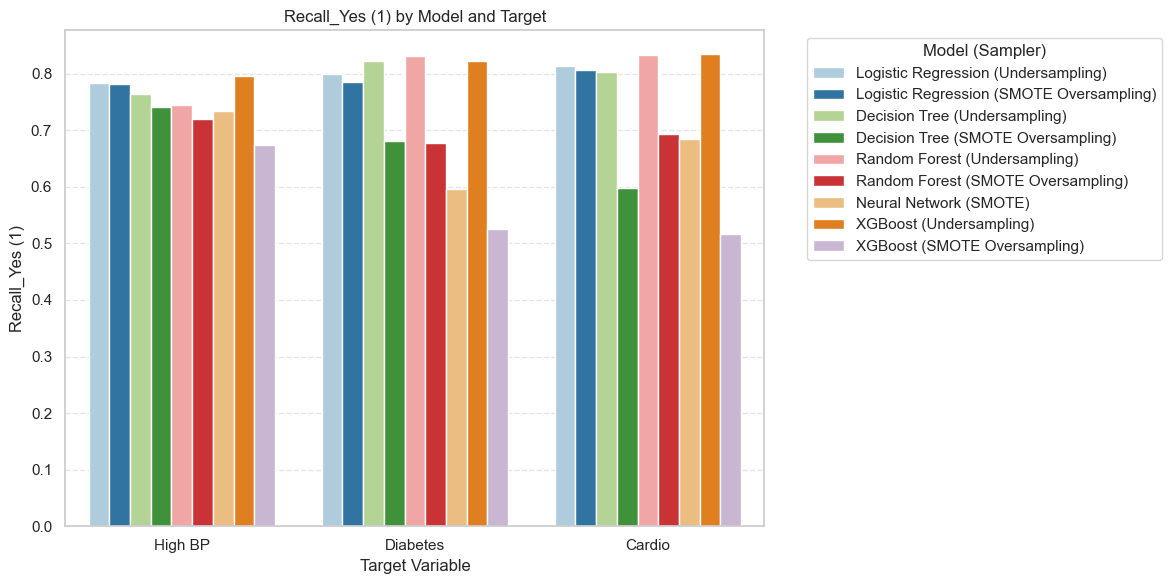

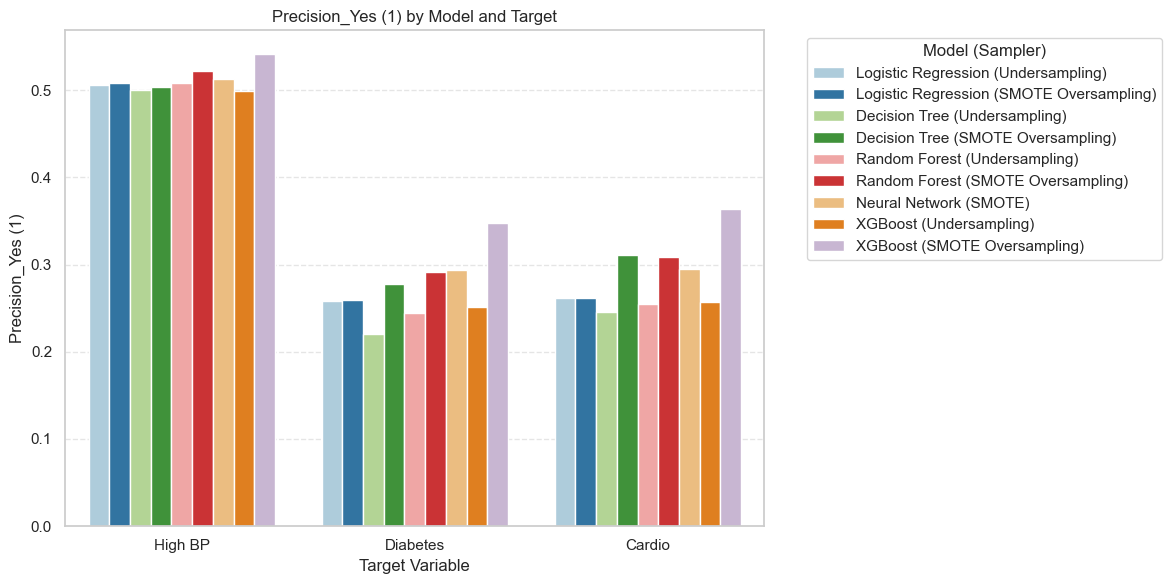

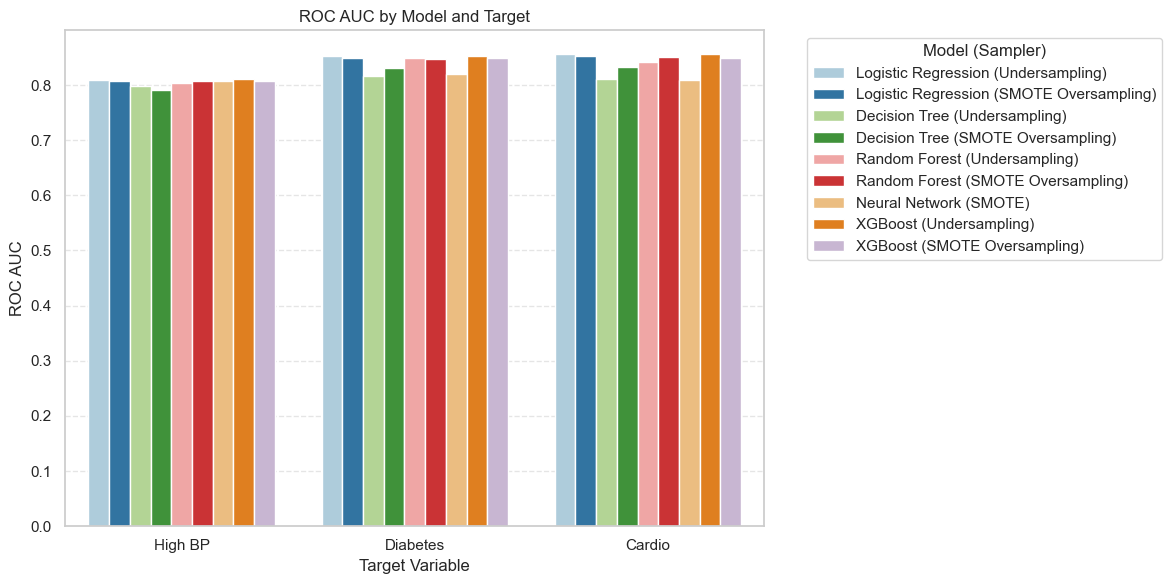

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# NOTE:
# The file "Final_Combined_Model_Evaluation_All_Pipelines.csv" was created manually
# by combining the evaluation results of all individual models 
# (Traditional, XGBoost, Neural). 
# It is NOT generated automatically by this notebook.
df = pd.read_csv(os.path.join(METRICS_DIR, "Final_Combined_Model_Evaluation_All_Pipelines.csv"))


# Clean column names
df["Model Label"] = df["Model"] + " (" + df["Sampler"] + ")"

# Define key metrics to visualize
metrics = ["F1_Yes (1)", "Recall_Yes (1)", "Precision_Yes (1)", "ROC AUC"]

theme = "Paired"

# Plotting and saving
for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x="Target", y=metric, hue="Model Label", palette=theme)
    plt.title(f"{metric} by Model and Target")
    plt.ylabel(metric)
    plt.xlabel("Target Variable")
    plt.legend(title="Model (Sampler)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Save the plot
    filename = f"{metric.replace(' ', '_').replace('(', '').replace(')', '')}_by_Target.png"
    plt.savefig(os.path.join(eval_plots_dir, filename), dpi=300)

    # Show the plot
    plt.show()


## Final Model Selection Summary

After evaluating multiple models (Logistic Regression, Decision Tree, Random Forest, Neural Network, XGBoost) across all three target variables, we have finalized the best model for each based on:

- **F1-score for the positive class (Yes)** — most critical metric  
- **Recall (Yes)** — important to minimize false negatives  
- **ROC AUC** — reflects overall model discriminative power  
- Visual inspection of plots: *F1, Precision, Recall, ROC AUC*  
- Consideration of model simplicity, speed, and interpretability

---

### Target 1: High Blood Pressure

- **Final Model:** `Logistic Regression (Undersampling)`
- **Why:**
  - F1 (Yes) = **0.615**
  - Recall (Yes) = **0.784**
  - ROC AUC = **0.810**
  - Performance is nearly identical to SMOTE but with fewer complications and simpler implementation.

---

### Target 2: Diabetes

- **Final Model:** `Logistic Regression (Undersampling)`
- **Why:**
  - F1 (Yes) = **0.390**
  - Recall (Yes) = **0.799**
  - ROC AUC = **0.852**
  - Best recall among all models (critical for identifying diabetic cases)
  - Maintains balance without overfitting

---

### Target 3: Cardiovascular Condition (Heart Disease or Stroke)

- **Final Model:** `Logistic Regression (Undersampling)`
- **Why:**
  - F1 (Yes) = **0.396**
  - Recall (Yes) = **0.814**
  - ROC AUC = **0.856**
  - Strong recall and F1, with excellent AUC, and remains interpretable

---

## Why Logistic Regression with Undersampling?

While SMOTE Oversampling gave similar results:

- **Undersampling** is:
  - Simpler and faster
  - Less prone to generating synthetic noise
  - Consistently high-performing with Logistic Regression
  - Adequate in our case since we have large enough datasets

Thus, we selected **Logistic Regression (Undersampling)** as the final model across **all three target variables**.

---

## Visual Justification

Included visualizations further support our selection:

- `F1_Yes_1_by_Target.png`
- `Precision_Yes_1_by_Target.png`
- `Recall_Yes_1_by_Target.png`
- `ROC_AUC_by_Target.png`

These plots clearly show that Logistic Regression (Undersampling) performs robustly across all relevant metrics.
